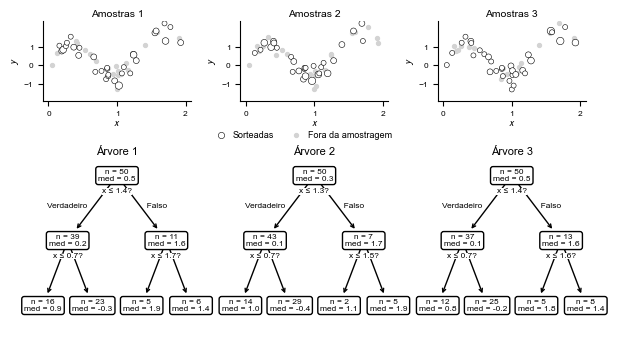

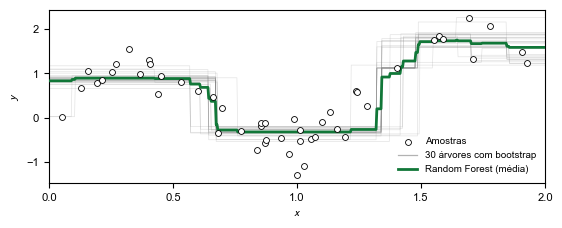

In [39]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
import numpy as np


cm = 1 / 2.54
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "font.size": 8,
})

COR_RF = "#117738"


def encurtar_texto(text):
    return (text
            .replace("True", "Verdadeiro")
            .replace("False", "Falso")
            .replace("samples", "n")
            .replace("value", "med"))


def reformatar_arvore(ax, fig, fontsize_condicao=6):
    # Passo 1: alterar textos e guardar condicoes pendentes
    pendentes = []
    for ann in list(ax.texts):
        original = ann.get_text()
        encurtado = encurtar_texto(original)
        if "x <=" in encurtado:
            linhas = encurtado.split("\n")
            linha_condicao = linhas[0]
            resto = "\n".join(linhas[1:])
            condicao_bonita = linha_condicao.replace("<=", "≤") + "?"
            ann.set_text(resto)
            pendentes.append((ann, condicao_bonita))
        else:
            if encurtado != original:
                ann.set_text(encurtado)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # Passo 2: posicionar a condicao logo abaixo do bbox novo
    for ann, condicao in pendentes:
        patch = ann.get_bbox_patch()
        if patch is not None:
            bbox = patch.get_window_extent(renderer)
        else:
            bbox = ann.get_window_extent(renderer)
        bbox_axes = bbox.transformed(ax.transAxes.inverted())
        x_centro = (bbox_axes.x0 + bbox_axes.x1) / 2
        y_inferior = bbox_axes.y0
        ax.text(
            x_centro, y_inferior - 0.018, condicao,
            ha="center", va="top",
            fontsize=fontsize_condicao,
            transform=ax.transAxes, zorder=200,
            bbox=dict(facecolor="white", edgecolor="none",
                      boxstyle="square,pad=0.05"),
        )


def add_axes_centered(fig, center_x, center_y, w, h):
    return fig.add_axes([center_x - w / 2, center_y - h / 2, w, h])


# ============================================================
# Dados de treino e funcao verdadeira
# ============================================================
def f_true(x):
    return np.sin(1.5 * np.pi * x) + 0.5 * x


np.random.seed(2)
n_data = 50
x_train = np.sort(np.random.uniform(0, 2, n_data))
y_train = f_true(x_train) + 0.30 * np.random.randn(n_data)
x_grid = np.linspace(0, 2, 600)
y_true = f_true(x_grid)

# ============================================================
# Floresta completa (uma unica fonte de aleatoriedade)
# As 3 primeiras arvores sao as exibidas na Figura 1
# ============================================================
MAX_DEPTH = 2   # testar 3: mais variabilidade entre as curvas da Figura 2
B = 30

rng = np.random.RandomState(2)
trees = []
indices_boot = []
all_predictions = np.zeros((B, len(x_grid)))

for b in range(B):
    idx = rng.choice(n_data, n_data, replace=True)
    indices_boot.append(idx)
    tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, random_state=b)
    tree.fit(x_train[idx].reshape(-1, 1), y_train[idx])
    trees.append(tree)
    all_predictions[b] = tree.predict(x_grid.reshape(-1, 1))

y_rf = all_predictions.mean(axis=0)

# ============================================================
# Figura 1: amostras bootstrap em cima, arvores embaixo
# (sem setas: as arvores sao independentes e paralelas)
# ============================================================
fig1 = plt.figure(figsize=(16 * cm, 9 * cm))

left_margin = 0.05
right_margin = 0.99

# linha 1: amostras bootstrap (compactas, como os resíduos do XGBoost)
am_y0_base = 0.68
am_h_base = 0.265
am_w_scale = 0.75
am_h_scale = 0.85

am_h = am_h_base * am_h_scale
am_center_y = am_y0_base + am_h_base / 2

slot_w = (right_margin - left_margin) / 3
col_w_am = slot_w * am_w_scale
centers_x = [left_margin + slot_w * (i + 0.5) for i in range(3)]
ax_amostras = [add_axes_centered(fig1, cx, am_center_y, col_w_am, am_h)
               for cx in centers_x]

# linha 2: arvores (altura equivalente a do XGBoost, com folga extra)
tree_y0 = 0.03
tree_h = 0.55
col_w_trees = (right_margin - left_margin) / 3
ax_trees = [fig1.add_axes([left_margin + i * col_w_trees, tree_y0,
                           col_w_trees, tree_h])
            for i in range(3)]

# amostras bootstrap
for k, ax in enumerate(ax_amostras):
    idx = indices_boot[k]
    contagem = np.bincount(idx, minlength=n_data)
    fora = contagem == 0          # observacoes out-of-bag
    dentro = ~fora

    ax.scatter(x_train[dentro], y_train[dentro],
               c="white", edgecolors="black", linewidth=0.4,
               s=8 + 5 * contagem[dentro], zorder=3,
               label="Sorteadas")
    
    ax.scatter(x_train[fora], y_train[fora],
               c="lightgray", s=8, zorder=2,
               label="Fora da amostragem")
    

    ax.set_xlim(-0.08, 2.08)
    ax.set_ylim(-1.9, 2.4)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(labelsize=6)
    ax.set_xlabel(r"$x$", fontsize=7, labelpad=2)
    ax.set_ylabel(r"$y$", fontsize=7, labelpad=2)
    ax.set_title(f"Amostras {k + 1}", fontsize=7.5, pad=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# legenda unica da figura, no vao entre as duas linhas
handles, labels = ax_amostras[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="center",
            bbox_to_anchor=(0.5, 0.603), ncol=2,
            fontsize=6.5, frameon=False,
            handletextpad=0.3, columnspacing=1.5)

# arvores
for k, ax in enumerate(ax_trees):
    plot_tree(
        trees[k], ax=ax, feature_names=["x"], filled=False,
        rounded=True, precision=1, fontsize=6,
        impurity=False, label="all",
    )
    reformatar_arvore(ax, fig1, fontsize_condicao=6)
    ax.set_title(f"Árvore {k + 1}", fontsize=8, y=0.90)

plt.savefig("figuras/exemplo_randomforest1.png", dpi=300)

# ============================================================
# Figura 2: agregacao
# ============================================================
fig2, ax_rf = plt.subplots(figsize=(14 * cm, 5.5 * cm), layout="constrained")

for b in range(B):
    ax_rf.plot(x_grid, all_predictions[b], color="gray", linewidth=0.5,
               alpha=0.22, zorder=1)


ax_rf.scatter(x_train, y_train, c="white", edgecolors="black",
              linewidth=0.6, s=18, marker="o", zorder=5,
              label="Amostras")
ax_rf.plot([], [], color="gray", linewidth=0.9, alpha=0.6,
           label=f"{B} árvores com bootstrap")
ax_rf.plot(x_grid, y_rf, color=COR_RF, linewidth=2.0,
           label="Random Forest (média)", zorder=4)

ax_rf.set_xlim(0, 2)
ax_rf.set_xticks(np.arange(0, 2.1, 0.5))
ax_rf.set_xlabel(r"$x$")
ax_rf.set_ylabel(r"$y$")
#ax_rf.set_title(f"{B} árvores com profundidade máxima {MAX_DEPTH}",
#                fontsize=9)
ax_rf.legend(loc="lower right", fontsize=7, frameon=False)

plt.savefig("figuras/exemplo_randomforest2.png", dpi=300)